### Генерация поэзии с помощью нейронных сетей: шаг 1
##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерироват стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [1]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
# __________end of block__________

In [2]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________

cpu device is available


#### 1. Загрузка данных.

In [4]:
# do not change the code in the block below
# __________start of block__________
# !wget https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt
    
with open('onegin.txt', 'r', encoding="utf-8") as iofile:
    text = iofile.readlines()
    
text = "".join([x.replace('\t\t', '').lower() for x in text])
# __________end of block__________

#### 2. Построение словаря и предобработка текста
В данном задании требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим токен `<sos>`.

In [5]:
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text.lower())) + ['<sos>']
num_tokens = len(tokens)

assert num_tokens == 84, "Check the tokenization process"

token_to_idx = {x: idx for idx, x in enumerate(tokens)}
idx_to_token = {idx: x for idx, x in enumerate(tokens)}

assert len(tokens) == len(token_to_idx), "Mapping should be unique"

print("Seems fine!")


text_encoded = [token_to_idx[x] for x in text]
# __________end of block__________

Seems fine!


__Ваша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Вы можете воспользоваться кодом с занятие №6 или же обратиться к следующим ссылкам:
* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

Данное задание является достаточно творческим. Не страшно, если поначалу оно вызывает затруднения. Последняя ссылка в списке выше может быть особенно полезна в данном случае.

Далее для вашего удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

In [6]:
# do not change the code in the block below
# __________start of block__________
batch_size = 256
seq_length = 100
start_column = np.zeros((batch_size, 1), dtype=int) + token_to_idx['<sos>']

def generate_chunk():
    global text_encoded, start_column, batch_size, seq_length

    start_index = np.random.randint(0, len(text_encoded) - batch_size*seq_length - 1)
    data = np.array(text_encoded[start_index:start_index + batch_size*seq_length]).reshape((batch_size, -1))
    yield np.hstack((start_column, data))
# __________end of block__________    

Пример батча:

In [21]:
r_c = next(generate_chunk())
s = r_c[0]
s = [idx_to_token[x] for x in s]
s

['<sos>',
 'r',
 ' ',
 'l',
 '’',
 'a',
 'b',
 'b',
 'e',
 '€',
 ',',
 ' ',
 'ф',
 'р',
 'а',
 'н',
 'ц',
 'у',
 'з',
 ' ',
 'у',
 'б',
 'о',
 'г',
 'о',
 'й',
 ',',
 '\n',
 'ч',
 'т',
 'о',
 'б',
 ' ',
 'н',
 'е',
 ' ',
 'и',
 'з',
 'м',
 'у',
 'ч',
 'и',
 'л',
 'о',
 'с',
 'ь',
 ' ',
 'д',
 'и',
 'т',
 'я',
 ',',
 '\n',
 'у',
 'ч',
 'и',
 'л',
 ' ',
 'е',
 'г',
 'о',
 ' ',
 'в',
 'с',
 'е',
 'м',
 'у',
 ' ',
 'ш',
 'у',
 'т',
 'я',
 ',',
 '\n',
 'н',
 'е',
 ' ',
 'д',
 'о',
 'к',
 'у',
 'ч',
 'а',
 'л',
 ' ',
 'м',
 'о',
 'р',
 'а',
 'л',
 'ь',
 'ю',
 ' ',
 'с',
 'т',
 'р',
 'о',
 'г',
 'о',
 'й',
 ',']

Далее вам предстоит написать код для обучения модели и генерации текста.

### Я буду копировать некоторые куски текста из приведённых примеров, так что, возможен "плагиат"

## Inputs & Targets:

In [22]:
from torch.autograd import Variable

In [167]:
# Turn string into list of longs
def char_tensor(string):
    tensor = torch.zeros(len(string)).long()
    for c in range(len(string)):
        tensor[c] = tokens.index(string[c])
    return Variable(tensor)

print(char_tensor('правилррр ,').unsqueeze(0))

tensor([[60, 61, 45, 47, 53, 56, 61, 61, 61,  1,  5]])


In [79]:
# Generates random training set with input & target
def random_training_set():    
    chunk = next(generate_chunk())
    inp = chunk[:, :-1]
    target = chunk[:, 1:]
    return torch.LongTensor(inp), torch.LongTensor(target)

inp, targ = random_training_set()
print(inp[0][:10])
print(targ[0][:10])

tensor([83,  1, 47, 61, 50, 57, 76,  1, 51, 53])
tensor([ 1, 47, 61, 50, 57, 76,  1, 51, 53, 61])


## Class for VanillaRNN:

In [50]:
nn.Embedding(5, 6)(torch.tensor([1, 2, 3]))

tensor([[ 0.5066, -0.5566, -1.6179, -0.2379,  0.0856,  0.2461],
        [-1.7172, -0.9068,  0.8230,  0.0341,  0.2657, -0.0765],
        [ 0.0159,  1.2078,  1.1192, -1.1998,  0.4498, -0.8794]],
       grad_fn=<EmbeddingBackward0>)

In [75]:
class VanillaRNN(nn.Module):
    def __init__(self, alphabet_size, hidden_size, num_layers=1):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = num_layers
        self.character_encoder = nn.Embedding(alphabet_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, batch_first=True)
        self.prob_decoder = nn.Linear(hidden_size, alphabet_size)
    
    def forward(self, batched_input, batched_hidden):
        batched_input = self.character_encoder(batched_input)
        batched_output, batched_hidden = self.rnn(batched_input, batched_hidden)
        batched_output = self.prob_decoder(batched_output.contiguous().view(-1, self.hidden_size))
        return batched_output, batched_hidden

    def init_hidden(self, batch_size):
        return Variable(torch.zeros(self.n_layers, batch_size, self.hidden_size))

In [83]:
rnn_model = VanillaRNN(10, 1, 1)

In [84]:
rnn_model.init_hidden(2)

tensor([[[0.],
         [0.]]])

In [89]:
rnn_model.forward(torch.LongTensor([[1], [2]]), rnn_model.init_hidden(2))

(tensor([[-1.0520, -0.1615,  0.4517, -0.4716, -0.7359,  1.3848,  0.8390,  0.0616,
           0.8330, -0.0897],
         [-1.0548, -0.1587,  0.4495, -0.4727, -0.7375,  1.3871,  0.8394,  0.0648,
           0.8341, -0.0915]], grad_fn=<AddmmBackward0>),
 tensor([[[-0.6125],
          [-0.6159]]], grad_fn=<StackBackward0>))

## Training:

In [230]:
def train(inp, target):
    global rnn_model, seq_length, criterion, optimizer, batch_size
    hidden = rnn_model.init_hidden(batch_size=batch_size)
    rnn_model.zero_grad()
    loss = 0

    for c in range(seq_length):
        # print(inp[:, c])
        output, hidden = rnn_model(inp[:, c].unsqueeze(1), hidden)
        loss += criterion(output, target[:, c])

    loss.backward()
    optimizer.step()

    return loss.item() / seq_length

## Evaluating:

In [217]:
def evaluate(prime_str='A', predict_len=100, temperature=0.8):
    global rnn_model
    hidden = rnn_model.init_hidden(batch_size=1)
    prime_input = char_tensor(prime_str).unsqueeze(0)
    predicted = prime_str

    # Use priming string to "build up" hidden state
    for p in range(len(prime_str) - 1):
        _, hidden = rnn_model(prime_input[:, p].unsqueeze(1), hidden)
    inp = prime_input[:, -1].unsqueeze(1)
    
    for p in range(predict_len):
        output, hidden = rnn_model(inp, hidden)
        
        # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        top_i = torch.multinomial(output_dist, 1).item()
        
        # Add predicted character to string and use as next input
        predicted_char = idx_to_token[top_i]
        # print(predicted_char)
        predicted += predicted_char
        inp = char_tensor(predicted_char).unsqueeze(0)

    return predicted

В качестве иллюстрации ниже доступен график значений функции потерь, построенный в ходе обучения авторской сети (сам код для ее обучения вам и предстоит написать).

In [220]:
import time, math

def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

In [321]:
n_epochs = 2000
print_every = 1
plot_every = 1
hidden_size = 200
lr = 0.004

rnn_model = VanillaRNN(alphabet_size=len(tokens), hidden_size=hidden_size, num_layers=1)
rnn_model.init_hidden(batch_size=batch_size)
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

start = time.time()
all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    loss = train(*random_training_set())       
    loss_avg += loss

    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))

    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0

 0s (1 0%) 4.4579]
 0s (2 0%) 4.0235]
 0s (3 0%) 3.5205]
 1s (4 0%) 3.1988]
 1s (5 0%) 3.0384]
 1s (6 0%) 2.9732]
 2s (7 0%) 2.9189]
 2s (8 0%) 2.8420]
 2s (9 0%) 2.7935]
 3s (10 0%) 2.7632]
 3s (11 0%) 2.7224]
 3s (12 0%) 2.6802]
 3s (13 0%) 2.6819]
 4s (14 0%) 2.6526]
 4s (15 0%) 2.6222]
 4s (16 0%) 2.6054]
 4s (17 0%) 2.6130]
 5s (18 0%) 2.5911]
 5s (19 0%) 2.5463]
 5s (20 1%) 2.5424]
 5s (21 1%) 2.5185]
 6s (22 1%) 2.5033]
 6s (23 1%) 2.5154]
 6s (24 1%) 2.4791]
 6s (25 1%) 2.4621]
 7s (26 1%) 2.4583]
 7s (27 1%) 2.4772]
 7s (28 1%) 2.4545]
 7s (29 1%) 2.4255]
 8s (30 1%) 2.4284]
 8s (31 1%) 2.4506]
 8s (32 1%) 2.3920]
 8s (33 1%) 2.4121]
 8s (34 1%) 2.4034]
 9s (35 1%) 2.3837]
 9s (36 1%) 2.4088]
 9s (37 1%) 2.3944]
 9s (38 1%) 2.3691]
 10s (39 1%) 2.3925]
 10s (40 2%) 2.3854]
 10s (41 2%) 2.3394]
 10s (42 2%) 2.3460]
 11s (43 2%) 2.3690]
 11s (44 2%) 2.3345]
 11s (45 2%) 2.3534]
 11s (46 2%) 2.3462]
 12s (47 2%) 2.3287]
 12s (48 2%) 2.2957]
 12s (49 2%) 2.3368]
 12s (50 2%) 2.276

KeyboardInterrupt: 

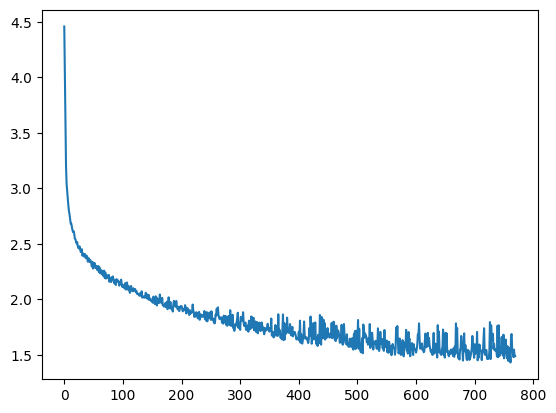

In [322]:
plt.plot(all_losses)

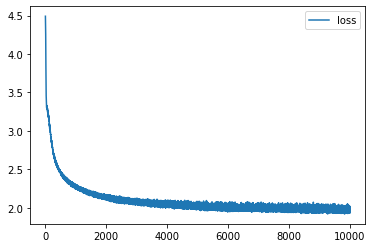

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [12]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''
    
    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else: 
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)
    
    #feed the seed phrase, if any
            
    # your code here
    
    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])

Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

### Сдача задания
Сгенерируйте десять последовательностей длиной 500, используя строку ' мой дядя самых честных правил'. Температуру для генерации выберите самостоятельно на основании визуального качества генериуремого текста. Не забудьте удалить все технические токены в случае их наличия.

Сгенерированную последовательность сохрание в переменную `generated_phrase` и сдайте сгенерированный ниже файл в контест.

In [323]:
seed_phrase = ' мой дядя самых честных правил'

In [334]:
generated_phrase = evaluate(seed_phrase, predict_len=470, temperature=1)
print(generated_phrase)

 мой дядя самых честных правила тень пьяный дежом бестого,
и дышать;
как замеморон,
в дверь явая,
заредкостит мира
прощет,
а топные дорелам,
уединенье
режден
младах,
на смотрить». —

зари блины
туми ленской, еще и другие, печальных мудоме рассказам обмордан!



xlii

мой дальною
как татилась
судьбы:
соне ласкорою! старым в кинец,
в гостина,
потом счастливой ничтожно свобам о семья.



lviii

коедеет доле
смирик,
вознами
симлава каплена их обедать невершеб и льму еще. при полей, в молон;
безмузы


In [325]:
generated_phrase = generated_phrase.replace('<sos>', " ")

In [326]:
generated_phrases = [generated_phrase]

In [328]:
# do not change the code in the block below
# __________start of block__________

import json
if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'
    

submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

with open('submission_dict9.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict.json`')
# __________end of block__________

File saved to `submission_dict.json`


На этом задание завершено. Поздравляем!